In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load cleaned data
df = pd.read_csv("data/cleaned/cleaned_border_crossing.csv")
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(49993, 10)


,port_name,state,port_code,border,date,measure,value,latitude,longitude,point
0,Richford,Vermont,203,US-Canada Border,2026-01-01,Personal Vehicles,4050,45.011740,-72.588559,POINT (-72.588559 45.01174)
1,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Trucks,208,31.334084,-109.948413,POINT (-109.948413 31.334084)
2,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Truck Containers Empty,103,31.334084,-109.948413,POINT (-109.948413 31.334084)
3,Sumas,Washington,3009,US-Canada Border,2026-01-01,Rail Containers Empty,338,49.002388,-122.264805,POINT (-122.264805 49.002388)
4,Vanceboro,Maine,105,US-Canada Border,2026-01-01,Rail Containers Loaded,5908,45.568761,-67.428541,POINT (-67.428541 45.568761)


In [8]:
# Total crossings per port
port_total = df.groupby("port_name")["value"].sum().rename("total_crossings")

# Average monthly crossings per port
port_avg = df.groupby("port_name")["value"].mean().rename("avg_crossings")

# Most common measure type per port
port_measure = df.groupby("port_name")["measure"].agg(lambda x: x.value_counts().index[0]).rename("top_measure")

# Which border the port is on
port_border = df.groupby("port_name")["border"].first().rename("border")

# Which state the port is in
port_state = df.groupby("port_name")["state"].first().rename("state")

# Combine into one dataframe
port_df = pd.concat([port_total, port_avg, port_border, port_state, port_measure], axis=1).reset_index()

print(port_df.shape)
port_df.head(10)

(111, 6)


,port_name,total_crossings,avg_crossings,border,state,top_measure
0,Alcan,655149,1742.417553,US-Canada Border,Alaska,Personal Vehicle Passengers
1,Alexandria Bay,8853146,20352.059770,US-Canada Border,New York,Trucks
2,Algonac,376783,4095.467391,US-Canada Border,Michigan,Personal Vehicles
3,Ambrose,11299,66.857988,US-Canada Border,North Dakota,Personal Vehicles
4,Andrade,11102734,54159.678049,US-Mexico Border,California,Personal Vehicle Passengers
5,Antler,84807,272.691318,US-Canada Border,North Dakota,Trucks
6,Bar Harbor,108803,2266.729167,US-Canada Border,Maine,Personal Vehicles
7,Baudette,1397154,3175.350000,US-Canada Border,Minnesota,Trucks
8,Beecher Falls,690855,1968.247863,US-Canada Border,Vermont,Personal Vehicle Passengers
9,Blaine,40352994,56516.798319,US-Canada Border,Washington,Personal Vehicle Passengers


In [9]:
# Encode border as numeric
port_df["border_encoded"] = (port_df["border"] == "US-Mexico Border").astype(int)

# Select features for clustering
features = port_df[["total_crossings", "avg_crossings", "border_encoded"]]

# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Features ready for clustering!")

Features ready for clustering!


c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

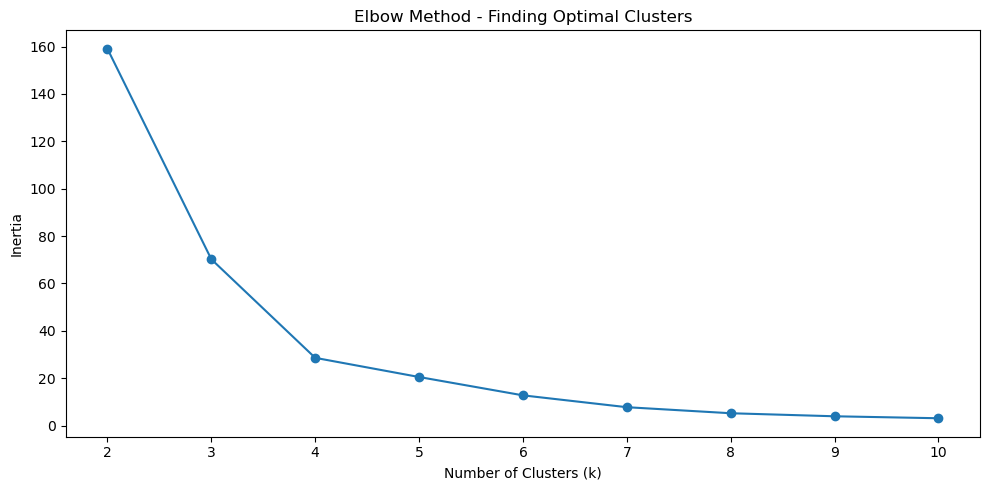

In [10]:
# Elbow method - finds optimal number of clusters
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method - Finding Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [11]:
# Build KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
port_df["cluster"] = kmeans.fit_predict(features_scaled)

# See how many ports are in each cluster
print(port_df["cluster"].value_counts())

# See cluster averages
print(port_df.groupby("cluster")[["total_crossings", "avg_crossings"]].mean())

# See which ports are in each cluster
for i in range(4):
    print(f"\n── Cluster {i} ──")
    print(port_df[port_df["cluster"] == i]["port_name"].values)

cluster
0    83
2    18
1     9
3     1
Name: count, dtype: int64
         total_crossings  avg_crossings
cluster                                
0           3.985973e+06    6215.008006
1           9.397470e+07  178903.666316
2           1.662802e+07   41663.174135
3           2.571015e+08  765182.919643

── Cluster 0 ──
['Alcan' 'Alexandria Bay' 'Algonac' 'Ambrose' 'Antler' 'Bar Harbor'
 'Baudette' 'Beecher Falls' 'Blaine' 'Boundary' 'Bridgewater'
 'Buffalo Niagara Falls' 'Calais' 'Cape Vincent' 'Carbury'
 'Champlain Rouses Point' 'Dalton Cache' 'Danville' 'Del Bonita'
 'Derby Line' 'Detroit' 'Dunseith' 'Eastport' 'Ferry' 'Fort Fairfield'
 'Fort Kent' 'Fortuna' 'Frontier' 'Grand Portage' 'Hannah' 'Hansboro'
 'Highgate Springs' 'Houlton' 'International Falls' 'Jackman'
 'Kenneth G Ward' 'Ketchikan' 'Lancaster' 'Laurier' 'Limestone'
 'Madawaska' 'Maida' 'Massena' 'Metaline Falls' 'Morgan' 'Neche'
 'Nighthawk' 'Noonan' 'Northgate' 'Norton' 'Ogdensburg' 'Opheim'
 'Oroville' 'Pembina' 'Pie

c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


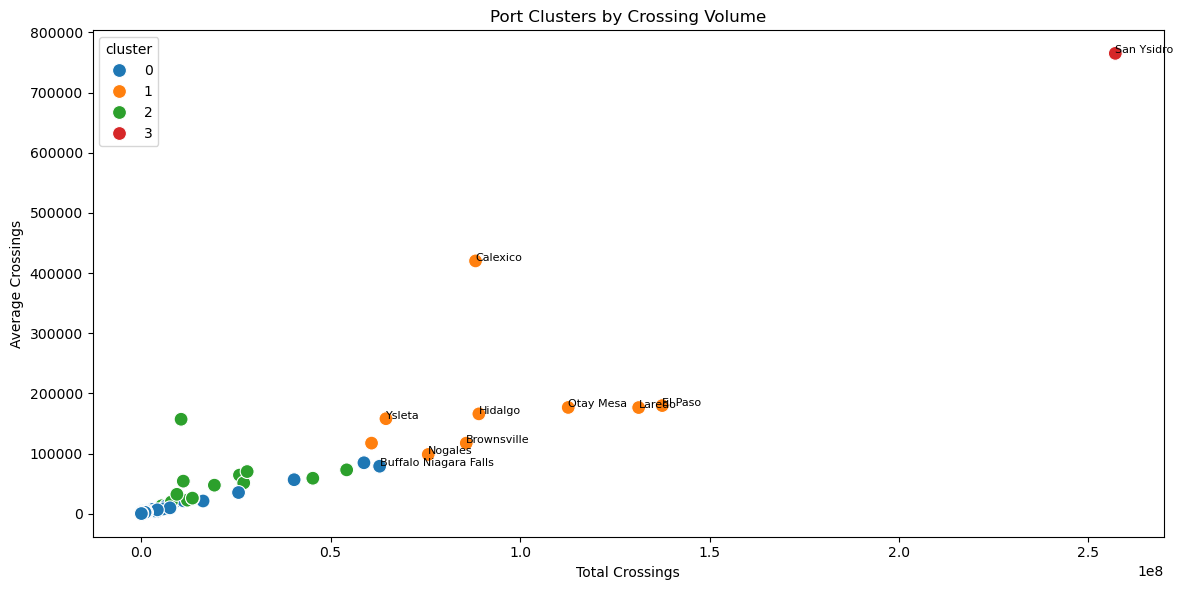

In [12]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=port_df,
    x="total_crossings",
    y="avg_crossings",
    hue="cluster",
    palette="tab10",
    s=100
)

# Label the biggest ports
for _, row in port_df.nlargest(10, "total_crossings").iterrows():
    plt.annotate(row["port_name"], 
                (row["total_crossings"], row["avg_crossings"]),
                fontsize=8, ha="left")

plt.title("Port Clusters by Crossing Volume")
plt.xlabel("Total Crossings")
plt.ylabel("Average Crossings")
plt.tight_layout()
plt.show()

In [13]:
# Save clustering results
port_df.to_csv("data/cleaned/port_clusters.csv", index=False)
print("Clustering results saved!")

# Final summary
print("\n── Cluster Summary ──")
summary = port_df.groupby("cluster").agg(
    num_ports=("port_name", "count"),
    avg_total_crossings=("total_crossings", "mean"),
    avg_monthly_crossings=("avg_crossings", "mean")
).round(0)
print(summary)

Clustering results saved!

── Cluster Summary ──
         num_ports  avg_total_crossings  avg_monthly_crossings
cluster                                                       
0               83            3985973.0                 6215.0
1                9           93974699.0               178904.0
2               18           16628016.0                41663.0
3                1          257101461.0               765183.0
